Epoch 01 | mistakes=1133/2573 | train_acc=0.3443 | val_acc=0.3214
Epoch 02 | mistakes=1117/2573 | train_acc=0.3245 | val_acc=0.3463
Epoch 03 | mistakes=1134/2573 | train_acc=0.3591 | val_acc=0.3354
Epoch 04 | mistakes=1121/2573 | train_acc=0.3669 | val_acc=0.3432
Epoch 05 | mistakes=1137/2573 | train_acc=0.3591 | val_acc=0.3323
Epoch 06 | mistakes=1112/2573 | train_acc=0.3436 | val_acc=0.3354
Epoch 07 | mistakes=1134/2573 | train_acc=0.3727 | val_acc=0.3261
Epoch 08 | mistakes=1150/2573 | train_acc=0.3719 | val_acc=0.3323
Epoch 09 | mistakes=1152/2573 | train_acc=0.3603 | val_acc=0.3183
Epoch 10 | mistakes=1151/2573 | train_acc=0.3828 | val_acc=0.3571
Epoch 11 | mistakes=1136/2573 | train_acc=0.3529 | val_acc=0.3401
Epoch 12 | mistakes=1127/2573 | train_acc=0.3576 | val_acc=0.3463
Epoch 13 | mistakes=1142/2573 | train_acc=0.3618 | val_acc=0.3370
Epoch 14 | mistakes=1141/2573 | train_acc=0.3828 | val_acc=0.3447
Epoch 15 | mistakes=1120/2573 | train_acc=0.3121 | val_acc=0.3245
Epoch 16 |

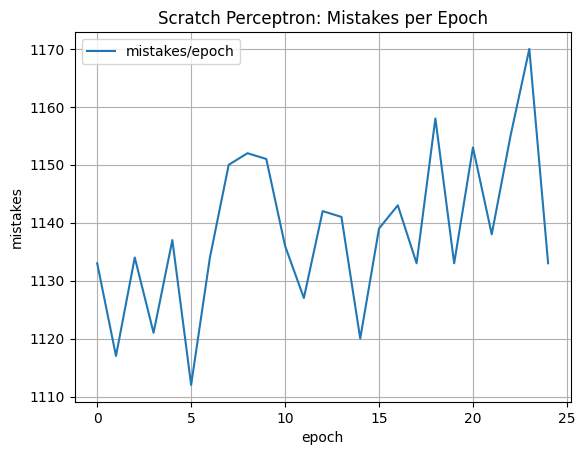

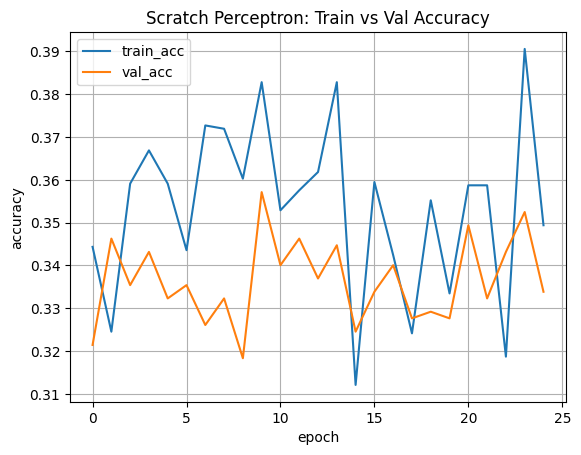


===== Scratch Perceptron (TEST) =====

Confusion Matrix (rows=true, cols=pred):
[[ 50  69  93]
 [ 67  97 103]
 [102  80 144]]

Accuracy: 0.36149068322981365
Balanced Accuracy: 0.34695424272154307

Per-class PR/RC/F1:
  0 (Down): P=0.228 R=0.236 F1=0.232 Support=212
  1 (Sideway): P=0.394 R=0.363 F1=0.378 Support=267
  2 (Up): P=0.424 R=0.442 F1=0.432 Support=326

Macro Avg: P=0.349 R=0.347 F1=0.348

Margin (top1-top2) stats:
  mean: 13.586076
  median: 9.422696
  p10: 1.504580
  p90: 30.825587
  min: 0.009425
  max: 92.393819

===== Sklearn Perceptron (TEST) =====

Confusion Matrix (rows=true, cols=pred):
[[ 50  44 118]
 [ 65  71 131]
 [ 59  61 206]]

Accuracy: 0.4062111801242236
Balanced Accuracy: 0.37788950003027527

Per-class PR/RC/F1:
  0 (Down): P=0.287 R=0.236 F1=0.259 Support=212
  1 (Sideway): P=0.403 R=0.266 F1=0.321 Support=267
  2 (Up): P=0.453 R=0.632 F1=0.528 Support=326

Macro Avg: P=0.381 R=0.378 F1=0.369

Margin (top1-top2) stats:
  mean: 13.871693
  median: 6.499042
 

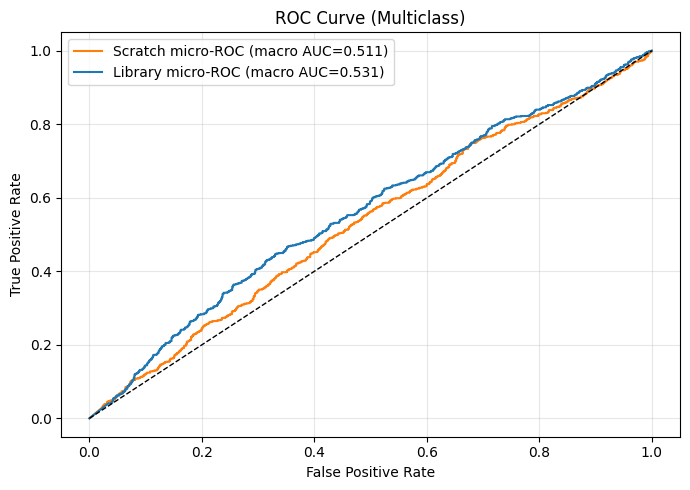

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    roc_curve,
    roc_auc_score
)

# =========================
# Config
# =========================
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"  # <- เปลี่ยนเป็น path ของคุณ
FEATURES = [
    'ma_gap_20', 'ma_gap_10', 'vol_10',
    'ret_2', 'ret_5',
    'ret_1',
    'ret_4',
    'vol_20',
    'ret_3'
]
TARGET_CANDIDATES = ["TargetClass", "Target_Class"]

TRAIN_RATIO = 0.8            # train_full : test = 80 : 20 (strict time-series)
VAL_RATIO_IN_TRAIN = 0.2     # เอาท้าย train_full ไปเป็น val (strict time-series)

EPOCHS = 25
LR = 1.0
SEED = 42

CLASS_LABELS = {0: "Down", 1: "Sideway", 2: "Up"}  # ปรับได้ตาม label จริง


# =========================
# 1) Helper: margin stats
# =========================
def margin_stats(scores):
    """
    scores: (N,K)
    margin = top1 - top2 (ยิ่งมากยิ่งมั่นใจเชิงคะแนน)
    """
    scores = np.asarray(scores)
    if scores.ndim != 2:
        raise ValueError("scores must be shape (N,K)")
    # เอา top2 แบบเร็ว
    part = np.partition(scores, kth=-2, axis=1)
    top2 = part[:, -2]
    top1 = part[:, -1]
    m = top1 - top2
    return {
        "mean": float(np.mean(m)),
        "median": float(np.median(m)),
        "p10": float(np.percentile(m, 10)),
        "p90": float(np.percentile(m, 90)),
        "min": float(np.min(m)),
        "max": float(np.max(m)),
    }


# =========================
# 2) Scratch Multiclass Perceptron (single-layer)
# =========================
class ScratchMulticlassPerceptron:
    def __init__(self, n_classes, n_features, lr=1.0, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, size=(n_classes, n_features))
        self.b = np.zeros(n_classes)
        self.lr = lr

        self.train_acc_history = []
        self.val_acc_history = []
        self.mistakes_history = []  # <- เพิ่มเก็บ mistakes/epoch

    def decision_function(self, X):
        return X @ self.W.T + self.b  # (N,K)

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)

    def _eval_acc(self, X, y):
        y_pred = self.predict(X)
        return float((y_pred == y).mean())

    def fit_time_series_strict(self, X_train, y_train, X_val=None, y_val=None, epochs=20):
        """
        strict time-series:
        - ไม่ shuffle
        - เดินตามลำดับเวลา
        - online update แบบ perceptron
        - เก็บ mistakes/epoch + train/val acc
        """
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train, dtype=int)
        N = X_train.shape[0]
        K = self.b.shape[0]

        # ต้องการ labels 0..K-1
        classes = np.unique(y_train)
        if not np.array_equal(classes, np.arange(classes.max() + 1)):
            raise ValueError("Label ควรเป็น 0..K-1 (ต่อเนื่อง)")

        have_val = (X_val is not None) and (y_val is not None)
        if have_val:
            X_val = np.asarray(X_val, dtype=float)
            y_val = np.asarray(y_val, dtype=int)

        for ep in range(1, epochs + 1):
            mistakes = 0

            for i in range(N):
                x = X_train[i]
                y_true = y_train[i]

                s = self.W @ x + self.b
                y_hat = int(np.argmax(s))

                if y_hat != y_true:
                    mistakes += 1
                    self.W[y_true] += self.lr * x
                    self.b[y_true] += self.lr
                    self.W[y_hat]  -= self.lr * x
                    self.b[y_hat]  -= self.lr

            self.mistakes_history.append(mistakes)

            tr_acc = self._eval_acc(X_train, y_train)
            self.train_acc_history.append(tr_acc)

            if have_val:
                va_acc = self._eval_acc(X_val, y_val)
                self.val_acc_history.append(va_acc)
                print(
                    f"Epoch {ep:02d} | mistakes={mistakes:4d}/{N} | "
                    f"train_acc={tr_acc:.4f} | val_acc={va_acc:.4f}"
                )
            else:
                print(
                    f"Epoch {ep:02d} | mistakes={mistakes:4d}/{N} | "
                    f"train_acc={tr_acc:.4f}"
                )

        return self


# =========================
# 3) Plot: mistakes + acc (train/val)
# =========================
def plot_training_curves(mistakes, train_acc, val_acc=None, title_prefix="Scratch Perceptron"):
    # Mistakes
    plt.figure()
    plt.plot(mistakes, label="mistakes/epoch")
    plt.xlabel("epoch")
    plt.ylabel("mistakes")
    plt.title(f"{title_prefix}: Mistakes per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_acc, label="train_acc")
    if val_acc is not None and len(val_acc) > 0:
        plt.plot(val_acc, label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{title_prefix}: Train vs Val Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================
# 4) Perceptron-friendly eval (6 items)
# =========================
def eval_perceptron(name, y_true, y_pred, scores, K, class_labels):
    """
    6 metrics:
    1) Confusion Matrix
    2) Accuracy
    3) Balanced Accuracy
    4) Macro-F1 + per-class P/R/F1
    5) (training-side) mistakes/epoch -> อยู่ใน scratch history (print/plot แยก)
    6) Margin stats (top1-top2)
    """
    print(f"\n===== {name} =====")

    # 1) Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm)

    # 2) Accuracy
    acc = accuracy_score(y_true, y_pred)
    print("\nAccuracy:", acc)

    # 3) Balanced Accuracy
    bacc = balanced_accuracy_score(y_true, y_pred)
    print("Balanced Accuracy:", bacc)

    # 4) Macro-F1 (+ per-class)
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(K), zero_division=0
    )
    macro_pr, macro_rc, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nPer-class PR/RC/F1:")
    for c in range(K):
        print(
            f"  {c} ({class_labels.get(c, str(c))}): "
            f"P={pr[c]:.3f} R={rc[c]:.3f} F1={f1[c]:.3f} Support={sup[c]}"
        )
    print(f"\nMacro Avg: P={macro_pr:.3f} R={macro_rc:.3f} F1={macro_f1:.3f}")

    # 6) Margin stats
    ms = margin_stats(scores)
    print("\nMargin (top1-top2) stats:")
    for k, v in ms.items():
        print(f"  {k}: {v:.6f}")


# =========================
# 5) Load data + strict sort by Date (if possible)
# =========================
df = pd.read_csv(CSV_PATH)

target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Target column not found. Tried {TARGET_CANDIDATES}")

needed = FEATURES + [target_col]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data = df[needed].dropna().copy()

# strict sort by Date if possible
if "Date" in df.columns:
    d = pd.to_datetime(df.loc[data.index, "Date"], errors="coerce")
    if d.notna().all():
        data = data.loc[d.sort_values().index]

X = data[FEATURES].to_numpy(float)
y = data[target_col].to_numpy(int)

# =========================
# =========================
N = len(X)

split_test = int(N * TRAIN_RATIO)
X_train_full, y_train_full = X[:split_test], y[:split_test]
X_test, y_test = X[split_test:], y[split_test:]

n_train_full = len(X_train_full)
split_val = int(n_train_full * (1 - VAL_RATIO_IN_TRAIN))
X_train, y_train = X_train_full[:split_val], y_train_full[:split_val]
X_val, y_val = X_train_full[split_val:], y_train_full[split_val:]

# =========================
# 7) Standardize with TRAIN only (no leakage)
# =========================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

K = int(np.max(y)) + 1
classes_full = np.arange(K)

if CLASS_LABELS is None:
    CLASS_LABELS = {c: str(c) for c in classes_full}

# =========================
# 8) Train: Scratch + Library
# =========================
scratch_model = ScratchMulticlassPerceptron(
    n_classes=K,
    n_features=X_train_sc.shape[1],
    lr=LR,
    seed=SEED
)
scratch_model.fit_time_series_strict(
    X_train_sc, y_train,
    X_val=X_val_sc, y_val=y_val,
    epochs=EPOCHS
)

# Plot mistakes + acc curves (scratch)  -> (Metric #5 อยู่ตรงนี้)
plot_training_curves(
    scratch_model.mistakes_history,
    scratch_model.train_acc_history,
    scratch_model.val_acc_history,
    title_prefix="Scratch Perceptron"
)

# Library model (sklearn) strict time-series
lib_model = SkPerceptron(
    random_state=SEED,
    max_iter=EPOCHS,
    tol=None,
    shuffle=False
)
lib_model.fit(X_train_sc, y_train)

# =========================
# 9) Evaluate on TEST: Scratch (6 metrics)
# =========================
sc_scores_test = scratch_model.decision_function(X_test_sc)
sc_pred_test = np.argmax(sc_scores_test, axis=1)

eval_perceptron(
    "Scratch Perceptron (TEST)",
    y_test, sc_pred_test, sc_scores_test,
    K, CLASS_LABELS
)

# =========================
# 10) Evaluate on TEST: Sklearn (6 metrics)
# =========================
sk_scores_test = lib_model.decision_function(X_test_sc)
if sk_scores_test.ndim == 1:
    # binary case -> make (N,2)
    sk_scores_test = np.column_stack([-sk_scores_test, sk_scores_test])

sk_pred_test = np.argmax(sk_scores_test, axis=1)

eval_perceptron(
    "Sklearn Perceptron (TEST)",
    y_test, sk_pred_test, sk_scores_test,
    K, CLASS_LABELS
)

# =========================
# 11) ROC Curve
# =========================
Y_test_bin = label_binarize(y_test, classes=classes_full)

# Convert decision function scores to probabilities using softmax 
# so they sum up to 1.0 per sample (required by multiclass roc_auc)
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

sc_prob_test = softmax(sc_scores_test)
sk_prob_test = softmax(sk_scores_test)

# Scratch
fpr_s, tpr_s, _ = roc_curve(Y_test_bin.ravel(), sc_prob_test.ravel())
roc_auc_s = roc_auc_score(y_test, sc_prob_test, multi_class='ovr', average='macro')

# Library
fpr_l, tpr_l, _ = roc_curve(Y_test_bin.ravel(), sk_prob_test.ravel())
roc_auc_l = roc_auc_score(y_test, sk_prob_test, multi_class='ovr', average='macro')

# ROC Curve (micro-averaged one-vs-rest)
plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, label=f'Scratch micro-ROC (macro AUC={roc_auc_s:.3f})', color='tab:orange')
plt.plot(fpr_l, tpr_l, label=f'Library micro-ROC (macro AUC={roc_auc_l:.3f})', color='tab:blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()